### Geospatial Foundation Models - Polimi

This notebook assumes you have downloaded a Lucas Chips dataset following instructions given in the related notebook of the Geospatial Foundation Model course at Polimi.
The author (Tito Capovilla) has provided 3 datasets of 200, 400 and 2000 images.
Data is available upon request.

Code contains sections sourced from the Terratorch Documentation, Geospatial Foundation Model course at Polimi
Including contributions from
Tutors / Contributors: Vasil Yordanov and Julia Anna Leonardi.

### Environment Setup

(Kernel restart is required after running the cell below)

In [2]:
%pip install -r requirements.txt
#%pip install gdown tensorboard
#%pip install git+https://github.com/IBM/terratorch.git

  Cloning https://github.com/IBM/terratorch.git to /private/var/folders/4g/6zj3klj51gv0d2sd8vh0m0080000gn/T/pip-install-68polj8u/terratorch_a34a4069e7b940e0b335afed7498a032
  Running command git clone --filter=blob:none --quiet https://github.com/IBM/terratorch.git /private/var/folders/4g/6zj3klj51gv0d2sd8vh0m0080000gn/T/pip-install-68polj8u/terratorch_a34a4069e7b940e0b335afed7498a032
  Resolved https://github.com/IBM/terratorch.git to commit d0c75e53a676d6aee3416efebedfb40cd5454a34
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of albumentations to determine which version is compatible with other requirements. This could take a while.
  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.5/644.5 kB 8.3 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build whee

### Lucas Chips Dataset

The following section lets you download the provided dataset. If files are unavailable contact the author.

In [3]:
import os
import gdown
from pathlib import Path


In [6]:
# Download the dataset from Google Drive
if not os.path.isfile('Lucas_Chips_Geo_Italy.tar.gz'):
    #gdown.download(id="1tbhK5TK7iRkKAK-ruCOQh1WaIQskrm_n") # 200 images
    #gdown.download(id="11rJaOh78H36fBziQ8D05KO5FnAZV1c4Z") # 400 images
    gdown.download(id="1oaY9U-AnsDpepIuEQy5P9V8lfm_j5q7m") # 2000 images
!tar -xzvf Lucas_Chips_Geo_Italy.tar.gz 2>/dev/null #removes tar warnings

Removing MacOs metadata files

In [7]:
!find Lucas_Chips_Geo_Italy -name '._*' -type f -delete
print("Successfully removed all '._*' files.")

Successfully removed all '._*' files.


Let's check the download was successful. You should have 10 folders and a csv File. 

In [8]:
dataset_path = Path('Lucas_Chips_Geo_Italy')
!ls "Lucas_Chips_Geo_Italy" 

1                            6
10                           7
2                            8
3                            9
4                            Lucas_Chips_Geo_Italy.tar.gz
5                            chips_LC_class.csv


List a few files from the first folder

In [8]:
!ls "Lucas_Chips_Geo_Italy/1/" | head

40862384.tif
40922348.tif
41062360.tif
41082420.tif
41142376.tif
41182444.tif
41202410.tif
41202420.tif
41202518.tif
41222376.tif


Dataset Plotting

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import pandas as pd

In [10]:
datasetinfo = glob.glob(str(dataset_path / '*.csv'))

if not datasetinfo:
    raise FileNotFoundError("No csv found")

print(f"Found {len(datasetinfo)} CSV files:")
for csv_file in datasetinfo:
    print(csv_file)

df = pd.read_csv(datasetinfo[0])
print(f"available dataset points: {len(df)}")
df.head()

Found 1 CSV files:
Lucas_Chips_Geo_Italy/chips_LC_class.csv
available dataset points: 1994


,Point_ID,STR18
0,45922254,1
1,49621950,1
2,44782128,1
3,44942370,1
4,42381944,1


/var/folders/4g/6zj3klj51gv0d2sd8vh0m0080000gn/T/ipykernel_18432/3836439097.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = 'STR18', data = df, palette = 'tab20c')


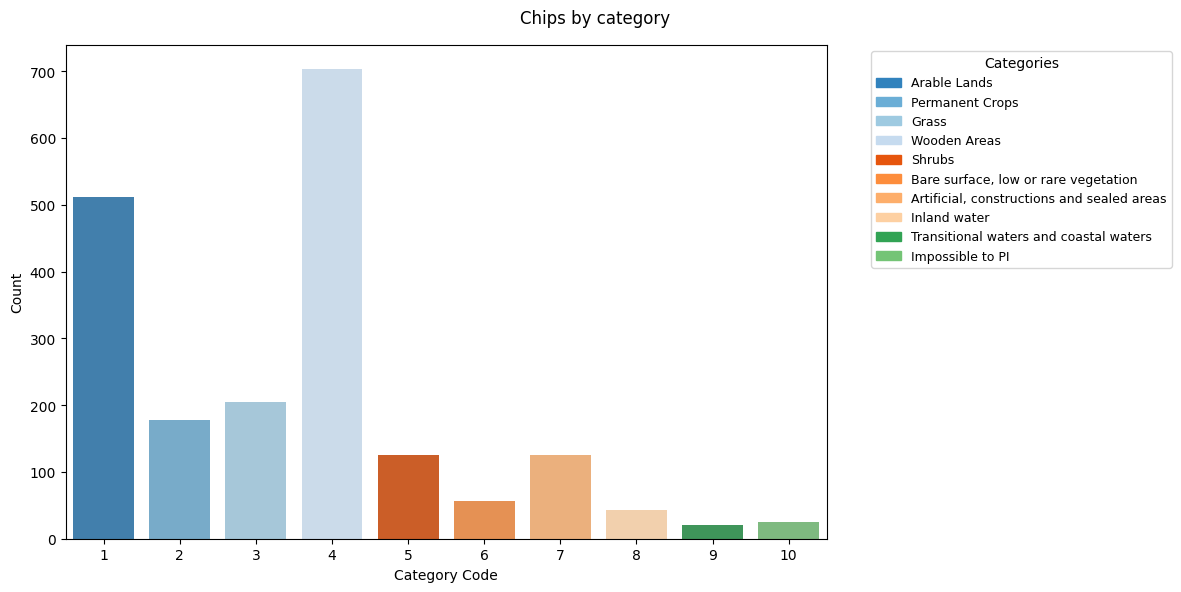

Available Chips: 

Key 1 	: Arable Lands (511 occurrences)
Key 2 	: Permanent Crops (178 occurrences)
Key 3 	: Grass (205 occurrences)
Key 4 	: Wooden Areas (704 occurrences)
Key 5 	: Shrubs (126 occurrences)
Key 6 	: Bare surface, low or rare vegetation (57 occurrences)
Key 7 	: Artificial, constructions and sealed areas (125 occurrences)
Key 8 	: Inland water (43 occurrences)
Key 9 	: Transitional waters and coastal waters (20 occurrences)
Key 10 	: Impossible to PI (25 occurrences)


In [13]:
plt.figure(figsize=(12, 6)) 
plt.suptitle('Chips by category')
n_categories = df['STR18'].nunique()

categories = { 1 : "Arable Lands",
                2 : "Permanent Crops",
                3 : "Grass",
                4: "Wooden Areas",
                5 : "Shrubs",
                6 : "Bare surface, low or rare vegetation",
                7 : "Artificial, constructions and sealed areas",
                8 : "Inland water",
                9: "Transitional waters and coastal waters",
                10: "Impossible to PI"
                }

#use any of these colors for plotting the histogram
#gradient_colors = sns.color_palette("RdPu", n_categories)
#diverging_colors = sns.color_palette("RdBu", 10)
#qualitative_colors = sns.color_palette("Set3", 10)

ax = sns.countplot(x = 'STR18', data = df, palette = 'tab20c')

# Add legend with category names
handles = [plt.Rectangle((0,0),1,1, color=sns.color_palette('tab20c')[i]) 
           for i in range(n_categories)]
labels = [categories[i+1] for i in range(n_categories)]

plt.legend(handles, labels, title='Categories', 
          bbox_to_anchor=(1.05, 1), loc='upper left', 
          frameon=True, fontsize=9)

plt.xlabel('Category Code')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



print("Available Chips: \n")
for key in categories:
    count = df['STR18'].value_counts().get(key, 0)
    print(f"Key {key} \t: {categories[key]} ({count} occurrences)")

Let's visualize some sample images

In [33]:
import rasterio as rio
from rasterio import plot as rioplot

Visualizing: Lucas_Chips_Geo_Italy/1/43902444.tif, of category : Arable Lands


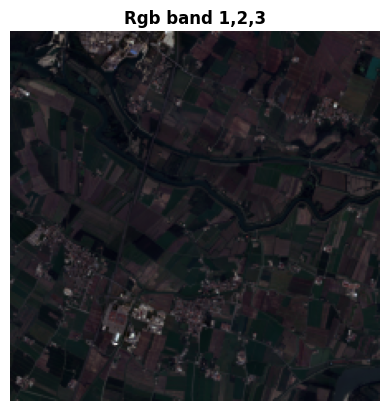

In [34]:
import warnings
warnings.filterwarnings('ignore')

# Get a sample image file from one of the category folders
sample_images = list(dataset_path.glob('1/*.tif'))  # Get images from folder '1'
if not sample_images:
    raise FileNotFoundError("No .tif files found in the dataset")

sample_image = sample_images[0]  # Pick the first image

sample_image_category_num = df.loc[df['Point_ID'] == int(sample_image.stem), 'STR18' ].iloc[0]
sample_image_category = categories[sample_image_category_num]
print(f"Visualizing: {sample_image}, of category : {sample_image_category}")


with rio.open(sample_image) as src:
        fig, ax = plt.subplots()
        rioplot.show((src,[1,2,3]),
                       ax=ax,
                       adjust = True,
                       #vmin=0, 
                       #vmax=3000
                       title = 'Rgb band 1,2,3',
                       with_bounds=False
                       )
        ax.axis('off')
        plt.show()

### Training


Libraries Import

In [ ]:
import torch
import terratorch
import numpy as np
import lightning.pytorch as pl
from terratorch.datamodules import GenericNonGeoClassificationDataModule
from terratorch.tasks import ClassificationTask

import warnings
warnings.filterwarnings('ignore')

#### Train Test Validation Split

In order to feed the model a training, validation and test set we are going to split the dataset onto an 80/20 split operating on the csv.


Since we are operating on a small dataset, we will initially try and use the same set for validation and test. An altenative would be to limit our fine tuning to the only categories where there is enough data do have all three sets.

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
df.head()

,Point_ID,STR18
0,45922254,1
1,49621950,1
2,44782128,1
3,44942370,1
4,42381944,1


In [38]:
SEED = 42
pl.seed_everything(SEED)

# Identify classes with fewer than 4 samples
class_counts = df['STR18'].value_counts()
rare_classes = class_counts[class_counts < 4].index.tolist()
common_classes = class_counts[class_counts >= 4].index.tolist()

print(f"Rare classes (< 4 samples): {rare_classes}")
print(f"Common classes (>= 4 samples): {common_classes}")

# Separate rare and common class samples
df_rare = df[df['STR18'].isin(rare_classes)]
df_common = df[df['STR18'].isin(common_classes)]

# Stratified split for common classes only
if len(df_common) > 0:
    train_common, val_common = train_test_split(
        df_common,
        test_size=0.2,
        stratify=df_common['STR18'],  # Stratify only common classes
        random_state=SEED
    )
else:
    train_common, val_common = pd.DataFrame(), pd.DataFrame()

# Random split for rare classes (no stratification)
if len(df_rare) > 0:
    train_rare, val_rare = train_test_split(
        df_rare,
        test_size=0.2,
        random_state=SEED  # No stratify - let them fall randomly
    )
else:
    train_rare, val_rare = pd.DataFrame(), pd.DataFrame()

# Combine both splits
train_df = pd.concat([train_common, train_rare], ignore_index=True)
val_df = pd.concat([val_common, val_rare], ignore_index=True)

print(f"\nTraining samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"\nTraining distribution:")
print(train_df['STR18'].value_counts().sort_index())
print(f"\nValidation distribution:")
print(val_df['STR18'].value_counts().sort_index())

Seed set to 42


Rare classes (< 4 samples): []
Common classes (>= 4 samples): [4, 1, 3, 2, 5, 7, 6, 8, 10, 9]

Training samples: 1595
Validation samples: 399

Training distribution:
STR18
1     409
2     142
3     164
4     563
5     101
6      46
7     100
8      34
9      16
10     20
Name: count, dtype: int64

Validation distribution:
STR18
1     102
2      36
3      41
4     141
5      25
6      11
7      25
8       9
9       4
10      5
Name: count, dtype: int64


For smaller Datasets some classes might have been lost in one of the sets. This will cause the training step to fail, make sure to manually adjust if necessary.

In [39]:
#Reporting categories where the split has caused to not have training or validation data
missing_in_val = set(train_df['STR18'].unique()) - set(val_df['STR18'].unique())
if missing_in_val:
    print(f"\nClasses only in training: {missing_in_val}")

In [40]:
train_df.head()

,Point_ID,STR18
0,47021582,3
1,46062276,3
2,43602552,6
3,48781860,2
4,48721852,4


In [41]:
val_df.head()

,Point_ID,STR18
0,45442254,1
1,49001976,1
2,41862406,4
3,42641804,5
4,45022236,4


Splitting the data for terratorch classification tasks requires us to create lists of files

In [42]:
def create_split_file(df, filename):
    ids = df['Point_ID'].astype(str).tolist()
    with open(filename, 'w') as f:
        f.write('\n'.join(ids))

    print(f"Created {filename} with {len(ids)} entries.")

create_split_file(train_df, 'train_split.txt')
create_split_file(val_df, 'val_split.txt')

Created train_split.txt with 1595 entries.
Created val_split.txt with 399 entries.


### Main Learning Parameters

Dataset paths and some training parameters

In [43]:
DATASET_PATH = Path("Lucas_Chips_Geo_Italy")
OUTPUT_PATH = Path("output/Terramind_Lucas_Chips_Geo_Italy")
BATCH_SIZE = 8 # num of images processed together in one forward/backward pass during training (8 small, 16 medium)
NUM_WORKERS = 2 # parallel loading and preprocessing of data
NUM_CLASSES = df['STR18'].nunique() # num of categories in the dataset
print(f"Number of classes : {NUM_CLASSES}")

MAX_EPOCH = 100 # testing 10 and 100 for the current dataset
LEARNING_RATE = 1.e-4 # controls the step size in grasiend descent (1.e-4 is a standard LR for large networks)


Number of classes : 10


Calculating the stds and mean of the dataset

In [44]:
import warnings
import logging

# Suppress rasterio warnings
warnings.filterwarnings('ignore', category=UserWarning)
logging.getLogger('rasterio').setLevel(logging.ERROR)

tif_files = glob.glob("Lucas_Chips_Geo_Italy/*/*.tif")
print(f"Found {len(tif_files)} total .tif files")

bands = 6
sum_vals = np.zeros(bands)
sum_sq_vals = np.zeros(bands)
count = 0

for f in tif_files:
    with rio.open(f) as src:
        for i in range(1, bands+1):
            band = src.read(i).astype(np.float32)
            sum_vals[i-1] += band.sum()
            sum_sq_vals[i-1] += (band ** 2).sum()
            if i == 1:
                count += band.size  # all bands have same size

dataset_means = sum_vals / count
dataset_stds = np.sqrt(sum_sq_vals / count - dataset_means ** 2)

print("Means:", dataset_means)
print("Stds:", dataset_stds)

Found 1994 total .tif files
Means: [0.08506267 0.08493301 0.05851657 0.24626011 0.18954353 0.11542881]
Stds: [0.11881323 0.11784236 0.11378918 0.10184967 0.07511264 0.05833632]


Since our classes are imbalanced we will ad an extra layer of info for the model to balance them. We will penalize the model more for errors on small classes. This may prove unnecessary when using focal loss

In [46]:
from sklearn.utils.class_weight import compute_class_weight

# Remap STR18 from 1-10 to 0-9 for PyTorch
train_df['label'] = train_df['STR18'] - 1
val_df['label'] = val_df['STR18'] - 1

# Now compute class weights on remapped labels
train_labels = train_df['label'].values  # Now 0-9

class_weights = compute_class_weight(
    'balanced', 
    classes=np.arange(NUM_CLASSES),  # [0, 1, 2, ..., 9]
    y=train_labels
)
print(f"Class weights: {class_weights}")
print(f"Classes (0-indexed): {np.arange(NUM_CLASSES)}")

# Instead of 'balanced', use a softer weighting
# class_weights_soft = np.sqrt(class_weights)  # Square root to reduce extremes
# print(f"Softened class weights: {class_weights_soft}")


Class weights: [0.38997555 1.12323944 0.97256098 0.28330373 1.57920792 3.4673913
 1.595      4.69117647 9.96875    7.975     ]
Classes (0-indexed): [0 1 2 3 4 5 6 7 8 9]


Renaming the folder for correct order

In [47]:
import shutil

# Rename folders to 0-indexed with zero-padding: 00, 01, 02, ..., 09
print("Renaming folders to 0-indexed with zero-padding...")

# First, rename to temporary names to avoid conflicts
for i in range(1, NUM_CLASSES + 1):
    old_path = DATASET_PATH / str(i)
    temp_path = DATASET_PATH / f"temp_{i}"
    if old_path.exists():
        old_path.rename(temp_path)
        print(f"Temp rename: {old_path} → {temp_path}")

# Then rename to final 0-indexed names with padding
for i in range(1, NUM_CLASSES + 1):
    temp_path = DATASET_PATH / f"temp_{i}"
    new_path = DATASET_PATH / f"{i-1:02d}"  # 00, 01, 02, ..., 09
    if temp_path.exists():
        temp_path.rename(new_path)
        print(f"Final rename: {temp_path} → {new_path}")

print("\n✅ New folder structure:")
# Sort the directory names before printing them
sorted_dirs = sorted([d.name for d in DATASET_PATH.iterdir() if d.is_dir()])
print(sorted_dirs)

# Display number of images for each folder, sorted by folder name
for dir_name in sorted_dirs:
    d_path = DATASET_PATH / dir_name
    # Filter out hidden files starting with '._'
    num_images = len([f for f in d_path.glob('*.tif') if not f.name.startswith('._')])
    print(f"{d_path.name}: {num_images} images")

print(f"\n The above data should match the previous classes distribution:")
print(df['STR18'].value_counts().sort_index())

Renaming folders to 0-indexed with zero-padding...
Temp rename: Lucas_Chips_Geo_Italy/1 → Lucas_Chips_Geo_Italy/temp_1
Temp rename: Lucas_Chips_Geo_Italy/2 → Lucas_Chips_Geo_Italy/temp_2
Temp rename: Lucas_Chips_Geo_Italy/3 → Lucas_Chips_Geo_Italy/temp_3
Temp rename: Lucas_Chips_Geo_Italy/4 → Lucas_Chips_Geo_Italy/temp_4
Temp rename: Lucas_Chips_Geo_Italy/5 → Lucas_Chips_Geo_Italy/temp_5
Temp rename: Lucas_Chips_Geo_Italy/6 → Lucas_Chips_Geo_Italy/temp_6
Temp rename: Lucas_Chips_Geo_Italy/7 → Lucas_Chips_Geo_Italy/temp_7
Temp rename: Lucas_Chips_Geo_Italy/8 → Lucas_Chips_Geo_Italy/temp_8
Temp rename: Lucas_Chips_Geo_Italy/9 → Lucas_Chips_Geo_Italy/temp_9
Temp rename: Lucas_Chips_Geo_Italy/10 → Lucas_Chips_Geo_Italy/temp_10
Final rename: Lucas_Chips_Geo_Italy/temp_1 → Lucas_Chips_Geo_Italy/00
Final rename: Lucas_Chips_Geo_Italy/temp_2 → Lucas_Chips_Geo_Italy/01
Final rename: Lucas_Chips_Geo_Italy/temp_3 → Lucas_Chips_Geo_Italy/02
Final rename: Lucas_Chips_Geo_Italy/temp_4 → Lucas_Chips_

We define the datamodule, to be fed into the training

In [49]:
datamodule = GenericNonGeoClassificationDataModule(
    task = "classification",

    batch_size = BATCH_SIZE,
    num_classes = NUM_CLASSES,
    num_workers = NUM_WORKERS,

    # we have all data together as downloaded and use split for separating training and validation
    train_data_root = str(DATASET_PATH),
    val_data_root = str(DATASET_PATH),
    test_data_root = str(DATASET_PATH),

    train_split=Path('train_split.txt'),
    val_split=Path('val_split.txt'),
    test_split=Path('val_split.txt'), # # ideally have a separate one for testing and val

    # These ensure the loader finds "45922254" inside "root/01/45922254.tif"
    allow_substring_split_file=True,   # Default is True, but good to be explicit
    ignore_split_file_extensions=True, # Default is True, ignores .tif vs .txt mismatch

    means = dataset_means.tolist(),
    stds = dataset_stds.tolist(),
    predict_data_root = OUTPUT_PATH,
)


### Model Definition

We will attemp to finetune:
- **Backbone**: TerraMind v1 base, TerraMind v1 Tiny
- **Decoder**: UNetDecoder, FCN Decoder, (experimental) IdentityDecoder, MLP Decoder (final 4 runs)
- **Loss**: ce loss, focal loss
- **Classes**: see previous part of notebook.  

In [51]:
# Contains commented code for the different decoder-head combos
# uncomment code sections to change finetuning parameters

model_args = dict(
    backbone="terramind_v1_base",  # large version: terramind_v1_large, smaller version: terramind_v1_tiny
    backbone_pretrained=True,
    backbone_modalities=["S2L2A"],
    num_classes=NUM_CLASSES,

    backbone_bands={
        "S2L2A": [
            "BLUE",
            "GREEN",
            "RED",
            "NIR_NARROW",
            "SWIR_1",
            "SWIR_2",  # fixed typo from documentation
        ]
    },

    # ==============================================================================
    # OPTION 1: UNetDecoder (Complex, Pyramidal, designed for segmentation)
    # ==============================================================================
    # decoder="UNetDecoder",
    # decoder_channels=[512, 256, 128, 64],
    # necks=[
    #     {"name": "SelectIndices", "indices": [2, 5, 8, 11]},
    #     {"name": "ReshapeTokensToImage", "remove_cls_token": False},
    #     {"name": "LearnedInterpolateToPyramidal"}
    # ],

    # ==============================================================================
    # OPTION 2: FCNDecoder (Convolutional, not ideal)
    # ==============================================================================
    # decoder="FCNDecoder",
    # decoder_channels=256,
    # necks=[
    #     {"name": "SelectIndices", "indices": [11]},
    #     {"name": "ReshapeTokensToImage", "remove_cls_token": False}
    # ],

    # ==============================================================================
    # OPTION 3: IdentityDecoder (Lightweight)
    # ==============================================================================
    # decoder="IdentityDecoder",
    # # decoder_channels=None,
    # necks=[
    #    {"name": "SelectIndices", "indices": [11]},
    # #   {"name": "ReshapeTokensToImage", "remove_cls_token": False}, # default
    #    {"name": "AggregateTokens", "pooling": "mean"}  # Aggregates tokens via mean pooling

    # ],

    # ==============================================================================
    # OPTION 4: MLPDecoder
    # ==============================================================================
    decoder="MLPDecoder",
    # decoder_channels defines the dimension of the hidden layer for the MLP
    decoder_channels=512, #try 512 for more capacity, 256 for less
    # out_dim=256, #not accepted
    necks=[
        {"name": "SelectIndices", "indices": [11]},
        {"name": "ReshapeTokensToImage", "remove_cls_token": False}, # default
    ],

    # head
    head_dropout=0.1,
)

In [ ]:
# Task with 0-indexed class names
task = ClassificationTask(
    model_args,
    model_factory = "EncoderDecoderFactory",
    loss="focal", # try 'focal' too or 'ce'
    lr=LEARNING_RATE,
    ignore_index=-1,
    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.05}, #change to 0.05 for finer 0.1 for coarser
    freeze_backbone=True,
    freeze_decoder=False,
    freeze_head=False,
    class_names=[categories[i+1] for i in range(NUM_CLASSES)],  # Display names
    class_weights=torch.tensor(class_weights, dtype=torch.float32) # remove if if you want it handled only by focal
)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/ibm-esa-geospatial/TerraMind-1.0-base/xet-read-token/fb96c70d0a5f68dcc44030b89cbfd8ec3fb0c67a "HTTP/1.1 200 OK"
INFO:root:Loaded weights for BLUE in position 0 of patch embed
INFO:root:Loaded weights for GREEN in position 1 of patch embed
INFO:root:Loaded weights for RED in position 2 of patch embed
INFO:root:Loaded weights for NIR_NARROW in position 3 of patch embed
INFO:root:Loaded weights for SWIR_1 in position 4 of patch embed
INFO:root:Loaded weights for SWIR_2 in position 5 of patch embed


### Training Configuration

## Training Configuration

We configure the **PyTorch Lightning Trainer**.  
We will:
- Train up to MAX_EPOCH epochs  
- Use mixed precision (16-bit) for faster training  
- Save the best checkpoint  


In [ ]:
# For CLASSIFICATION (not segmentation)
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath=OUTPUT_PATH / "checkpoints/",
    mode="max",
    monitor="val/Accuracy",  # Changed from val/mIoU
    filename="best-accuracy",
    save_weights_only=True,
)

# Lightning Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices="auto",
    num_nodes=1,
    precision="16-mixed",  # Speed up training with half precision, delete for full precision training.
    logger=True,  # Uses TensorBoard by default
    max_epochs=MAX_EPOCH, # For demos
    log_every_n_steps=5,
    callbacks=[checkpoint_callback, pl.callbacks.RichProgressBar(), pl.callbacks.LearningRateMonitor(logging_interval="epoch")],
    default_root_dir=OUTPUT_PATH,
)

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (mps), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (mps), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
# Start training
trainer.fit(task, datamodule=datamodule)

In [ ]:
# After training completes, launch TensorBoard
%load_ext tensorboard
%tensorboard --logdir output/Terramind_Lucas_Chips_Geo_Italy/lightning_logs

### Model Evaluation

In [ ]:
# Let's test the fine-tuned model
best_ckpt_path = OUTPUT_PATH / "checkpoints/best-accuracy.ckpt" 
trainer.test(task, datamodule=datamodule, ckpt_path=best_ckpt_path)  # Changed model to task


Additional data and visualization available in the dedicated folder